# Linear Regression

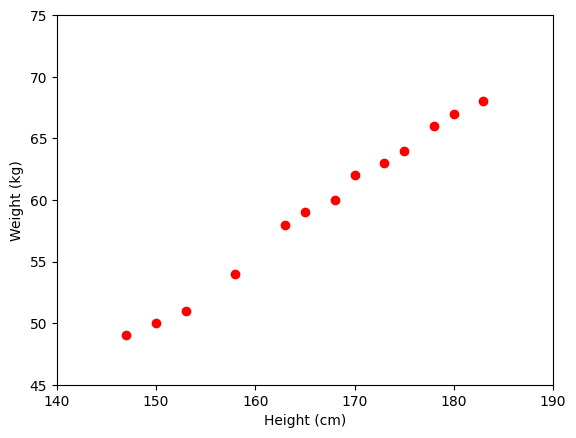

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# Visualize data
plt.plot(X, y, 'ro') #red-circle marker
plt.axis([140, 190, 45, 75]) #xmin, xmax, ymin, ymax
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

w =  [[-33.73541021]
 [  0.55920496]]


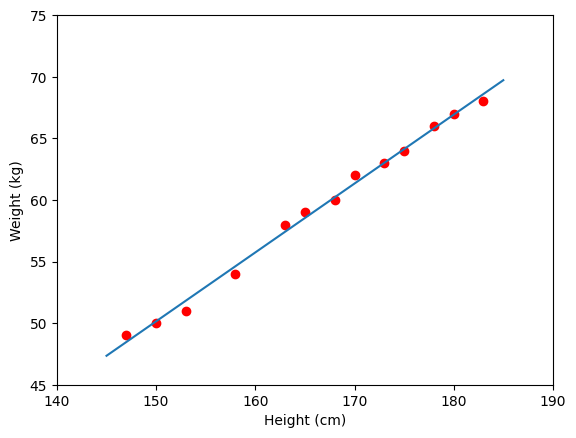

In [2]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b) #pseudo inverse
print('w = ', w)
# Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, y.T, 'ro')     # data
plt.plot(x0, y0)             # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()


In [3]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


**Retest according to scikit-learn linear_model**

In [16]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-33.73541021   0.55920496]]
Solution found by (5):  [[-33.73541021   0.55920496]]


* Hàm y là 1 hàm tuyến tính theo cả w và x. Nhưng trên thực tế, có thể áp dụng
Linear Regression cho các mô hình chỉ cần tuyến tính theo w. Với mỗi dữ liệu đầu vào X, chúng ta tính toán dữ liệu mới X* rồi áp dụng Linear Regression với dữ liệu mới này.

**Hạn chế**
* Linear Regression rất nhạy cảm với nhiễu (sensitive to noise). Với ví dụ trên, chỉ cần 1 cặp dữ liệu nhiễu là kết quả sẽ sai khác đi rất nhiều. Vì vậy, trước khi thực hiện Linear Regression, các nhiễu cần phải được loại bỏ. Bước đó gọi là tiền xử lí (Pre-processing)
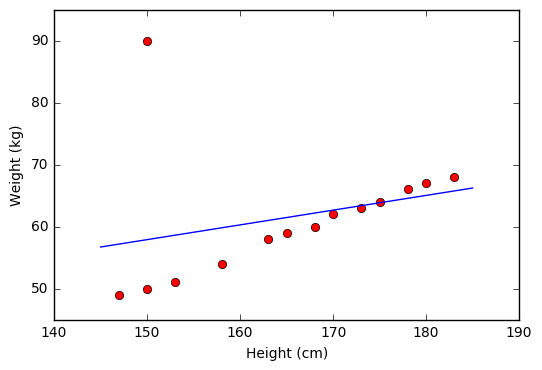
* Không biểu diễn được các mô hình phức tạp, mặc dù thấy rằng có thể áp dụng được nếu quan hệ giữa outcome và input không nhất thiết phải tuyến tính nhưng mối quan hệ này vẫn đơn giản nhiều so với các mô hình thực tế.